In [ ]:


import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("Environment ready. Libraries imported successfully.")






In [22]:
# Load dataset
import pandas as pd
df = pd.read_csv("combined_data.csv.xls")

# Replace missing values with the mean of each column
df = df.fillna(df.mean())

# Align features
FEATURES = ["Ax","Ay","Az","Gx","Gy","Gz","Temp1","Temp2","Flag","Capteur1_cm","Capteur2_cm"]

print("Dataset loaded and cleaned.")
print(df.head())

print(df[['Temp1','Temp2']].max())
print(df[['Capteur1_cm', 'Capteur2_cm']].min())


Dataset loaded and cleaned.
   Timestamp    Ax    Ay     Az    Gx    Gy    Gz  Col8  Temp1  Temp2  Flag  \
0     113251 -0.58  0.20 -10.58  0.24  0.14  0.05     1   38.0   31.0     0   
1     113326 -0.57  0.28 -10.56  0.10 -0.06  0.07     1   38.0   31.0     0   
2     113401 -0.60  0.31 -10.52  0.01 -0.01  0.05     1   38.0   31.0     0   
3     113477 -0.57  0.34 -10.54  0.03  0.03  0.11     1   38.0   31.0     0   
4     113552 -0.70  0.23 -10.54 -0.10  0.42 -0.10     1   38.0   31.0     0   

   Capteur1_cm  Capteur2_cm  
0        12.25         4.39  
1        12.71         4.30  
2        12.73         4.39  
3        12.67         4.39  
4        12.79         4.37  
Temp1    38.0
Temp2    39.0
dtype: float64
Capteur1_cm    0.14
Capteur2_cm    2.76
dtype: float64


In [23]:
import pandas as pd
df = pd.read_csv("combined_data.csv.xls")
def assign_label(row):
    if row["Temp1"] > 30 or row["Temp2"] > 30 & row["Capteur1_cm"] < 1 or row["Capteur2_cm"] < 1: 
    
        return 1 # EVACUATE
    else:
        return 0 # SAFE

df["risk_label"] = df.apply(assign_label, axis=1)

print("Labels generated successfully!")
print(df[["Temp1","Temp2","Capteur1_cm","Capteur2_cm","risk_label"]].head(200))


Labels generated successfully!
     Temp1  Temp2  Capteur1_cm  Capteur2_cm  risk_label
0     38.0   31.0        12.25         4.39           1
1     38.0   31.0        12.71         4.30           1
2     38.0   31.0        12.73         4.39           1
3     38.0   31.0        12.67         4.39           1
4     38.0   31.0        12.79         4.37           1
..     ...    ...          ...          ...         ...
195   37.0   32.0         6.52         4.39           1
196   37.0   32.0         2.88         4.39           1
197   37.0   32.0        12.19         4.37           1
198   37.0   32.0         9.66         4.39           1
199   37.0   32.0        12.19         4.37           1

[200 rows x 5 columns]


In [12]:
from sklearn.model_selection import train_test_split
X = df[FEATURES]
y = df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Data split complete.")


Data split complete.


In [24]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [27]:
 from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Model training complete!")


Model training complete!


In [28]:
joblib.dump(model, "evacuation_rf_model.pkl")
joblib.dump(scaler, "evacuation_scaler.pkl")

print("Model and scaler saved successfully!")


Model and scaler saved successfully!


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


ValueError: The number of FixedLocator locations (1), usually from a call to set_ticks, does not match the number of labels (4).

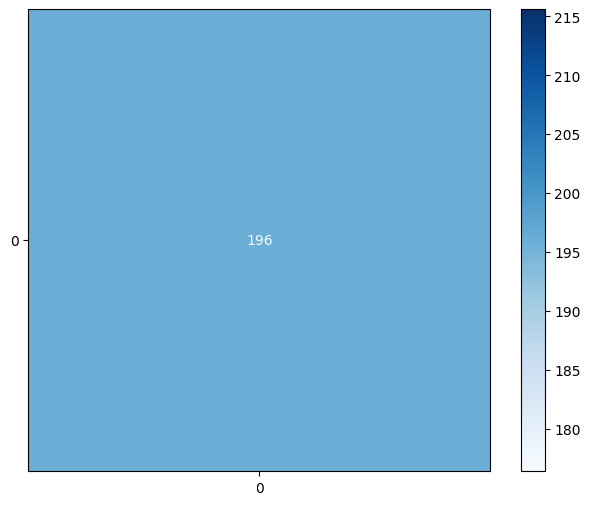

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Define the exact order of labels
my_labels = ["SAFE", "WATCH", "DANGER", "EVACUATE"]

# 3. Create the plot and force the display labels
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=my_labels)
disp.plot(cmap=plt.cm.Blues, ax=ax)

# 4. Final safety adjustments
plt.title("Structural Evacuation Confusion Matrix")
plt.tight_layout() # This forces the labels to fit inside the image
plt.show()

In [ ]:
deployed_model = joblib.load("evacuation_rf_model.pkl")
deployed_scaler = joblib.load("evacuation_scaler.pkl")

status_labels = {0: "SAFE", 1: "WATCH", 2: "DANGER", 3: "EVACUATE"}

def live_monitor_simulation(seconds=10, path_threshold=1.0):
    print("--- REAL-TIME STRUCTURAL MONITORING ---")
    for i in range(seconds):
        # Example simulated input
        Ax, Ay, Az = np.random.uniform(-1,1), np.random.uniform(-1,1), np.random.uniform(-12,-9)
        Gx, Gy, Gz = np.random.uniform(-5,5), np.random.uniform(-5,5), np.random.uniform(-5,5)
        Temp1, Temp2 = np.random.uniform(20,40), np.random.uniform(20,40)
        Flag = np.random.choice([0,1])
        Capteur1_cm = np.random.uniform(0.0, 12.0)
        Capteur2_cm = np.random.uniform(0.0, 12.0)

        current_reading = pd.DataFrame([[Ax,Ay,Az,Gx,Gy,Gz,Temp1,Temp2,Flag,Capteur1_cm,Capteur2_cm]],
                                       columns=FEATURES)
        current_scaled = deployed_scaler.transform(current_reading)
        prediction = deployed_model.predict(current_scaled)[0]
        status = status_labels[prediction]

        print(f"Time {i}s | Ax:{Ax:.2f} Ay:{Ay:.2f} Az:{Az:.2f} | Temp:{Temp1:.1f}/{Temp2:.1f}°C | STATUS: {status}")

        if status == "EVACUATE":
            if Capteur1_cm <= path_threshold:
                print("⚠️ Path A blocked → Choosing Path B")
            else:
                print("✅ Path A clear → Choosing Path A")
            print("🚨 EMERGENCY WARNING: ACTIVATING SMART BUILDING ALARMS 🚨")
        time.sleep(0.5)

# Run simulation
live_monitor_simulation()


In [ ]:
import serial
import time
import joblib
import pandas as pd
import numpy as np

# ==========================================
# 1. LOAD THE TRAINED AI MODEL & SCALER
# ==========================================
print("Loading AI Model and Scaler...")
try:
    # Load your trained model and scaler files directly from the directory
    deployed_model = joblib.load("evacuation_rf_model.pkl")
    deployed_scaler = joblib.load("evacuation_scaler.pkl")
    print("Model and scaler loaded successfully!")
except Exception as e:
    print(f"Error loading files: {e}")
    print("Ensure 'evacuation_rf_model.pkl' and 'evacuation_scaler.pkl' are in this same folder.")
    io_error = True

if 'io_error' not in locals():
    # Define features and labels exactly as matching your trained model layout
    FEATURES = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz", "Temp1", "Temp2", "Flag", "Capteur1_cm", "Capteur2_cm"]
    status_labels = {0: "SAFE", 1: "WATCH", 2: "DANGER", 3: "EVACUATE"}
    path_threshold = 1.0

    # ==========================================
    # 2. CONNECT TO BOTH USB COM PORTS
    # ==========================================
    # Change COM3 and COM4 if Windows Device Manager assigned different ports to your boards
    PORT_ARDUINO_1 = 'COM5'  # Node A: Ax, Ay, Az, Gx, Gy, Gz, Temp1, Flag
    PORT_ARDUINO_2 = 'COM6'  # Node B: Temp2, Capteur1_cm, Capteur2_cm
    BAUD_RATE = 9600

    print(f"Opening port connection to Arduino 1 ({PORT_ARDUINO_1})...")
    print(f"Opening port connection to Arduino 2 ({PORT_ARDUINO_2})...")

    try:
        arduino_1 = serial.Serial(PORT_ARDUINO_1, BAUD_RATE, timeout=1)
        arduino_2 = serial.Serial(PORT_ARDUINO_2, BAUD_RATE, timeout=1)
        time.sleep(2)  # Give both hardware units time to finish booting up
        print("Hardware links fully operational!")
        connection_success = True
    except Exception as e:
        print(f"Connection failed! Close Arduino Serial Monitors and try again. Error: {e}")
        connection_success = False

    # ==========================================
  # ==========================================
    # 3. LIVE DATA INTEGRATION & PREDICTION LOOP
    # ==========================================
    if connection_success:
        print("\n--- REAL-TIME STRUCTURAL MONITORING ACTIVE ---")
        try:
            while True:
                # Process data frames only when both serial registers have incoming data lines
                if arduino_1.in_waiting > 0 and arduino_2.in_waiting > 0:
                    
                    # FIXED: Added errors='ignore' to prevent crashes from initial startup noise
                    raw_data_1 = arduino_1.readline().decode('utf-8', errors='ignore').strip()
                    raw_data_2 = arduino_2.readline().decode('utf-8', errors='ignore').strip()
                    
                    try:
                        # Split string lines by commas and transform entries to float values
                        list_1 = [float(x) for x in raw_data_1.split(',')]
                        list_2 = [float(x) for x in raw_data_2.split(',')]
                        
                        # Guard condition: ensure transmissions are full frames before parsing
                        if len(list_1) != 8 or len(list_2) != 3:
                            continue
                        
                        # Map input features from the two separate streams
                        Ax, Ay, Az, Gx, Gy, Gz, Temp1, Flag = list_1
                        Temp2, Capteur1_cm, Capteur2_cm = list_2
                        
                        # Package individual metrics into the precise array sequence used during model training
                        combined_data = [Ax, Ay, Az, Gx, Gy, Gz, Temp1, Temp2, Flag, Capteur1_cm, Capteur2_cm]

                        # Format array as a DataFrame row and push it through the normalization and ML pipelines
                        current_reading = pd.DataFrame([combined_data], columns=FEATURES)
                        current_scaled = deployed_scaler.transform(current_reading)
                        prediction = deployed_model.predict(current_scaled)[0]
                        status = status_labels[prediction]
                        
                        # Output clear system updates down to the notebook console screen
                        print(f"Ax: {Ax:.2f} Ay: {Ay:.2f} Az: {Az:.2f} | Temp: {Temp1:.1f}/{Temp2:.1f}°C | STATUS: {status}")
                        
                        # Active evacuation routing mechanism
                        if status == "EVACUATE":
                            print("\n🚨 EMERGENCY WARNING: ACTIVATING SMART BUILDING ALARMS 🚨")
                            if Capteur1_cm <= path_threshold:
                                print("=> Path A blocked -> Directing Evacuation to Path B\n")
                            else:
                                print("=> Path A clear -> Directing Evacuation to Path A\n")

                    except ValueError:
                        # Gracefully disregard noise spikes or corrupted characters from the serial buffer
                        pass 

                time.sleep(0.05)  # Restrict CPU overhead

        except KeyboardInterrupt:
            print("\nMonitoring system paused by user.")
        finally:
            # Safely release the serial channel holds so COM ports don't lock out
            arduino_1.close()
            arduino_2.close()
            print("Serial communication lines closed cleanly.")

In [ ]:
!pip install pyserial

In [1]:
import serial
import time
import joblib
import pandas as pd
import numpy as np

# ==========================================
# 1. LOAD THE TRAINED AI MODEL & SCALER
# ==========================================
print("Loading AI Model and Scaler...")
try:
    deployed_model = joblib.load("evacuation_rf_model.pkl")
    deployed_scaler = joblib.load("evacuation_scaler.pkl")
    print("Model and scaler loaded successfully!")
except Exception as e:
    print(f"Error loading files: {e}")
    print("Ensure 'evacuation_rf_model.pkl' and 'evacuation_scaler.pkl' are in this same folder.")

# System Configuration
FEATURES = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz", "Temp1", "Temp2", "Flag", "Capteur1_cm", "Capteur2_cm"]
status_labels = {0: "SAFE", 1: "WATCH", 2: "DANGER", 3: "EVACUATE"}
path_threshold = 1.0

# COM Port Configuration
PORT_ARDUINO_1 = 'COM5'  # Part A Node
PORT_ARDUINO_2 = 'COM6'  # Part B Node
BAUD_RATE = 9600

print(f"Opening port connection to Arduino 1 ({PORT_ARDUINO_1})...")
print(f"Opening port connection to Arduino 2 ({PORT_ARDUINO_2})...")

# Wrapping the whole lifecycle in a master try block to protect COM port states
try:
    arduino_1 = serial.Serial(PORT_ARDUINO_1, BAUD_RATE, timeout=1)
    arduino_2 = serial.Serial(PORT_ARDUINO_2, BAUD_RATE, timeout=1)
    time.sleep(2)  # Give Arduinos a moment to stable boot after connection
    print("Hardware links fully operational!")
    print("\n--- REAL-TIME STRUCTURAL MONITORING ACTIVE ---")
    
    # ==========================================
    # 2. LIVE DATA INTEGRATION & PREDICTION LOOP
    # ==========================================
    while True:
        if arduino_1.in_waiting > 0 and arduino_2.in_waiting > 0:
            
            # Read lines and ignore startup byte anomalies safely
            raw_data_1 = arduino_1.readline().decode('utf-8', errors='ignore').strip()
            raw_data_2 = arduino_2.readline().decode('utf-8', errors='ignore').strip()
            
            try:
                # Convert reading blocks into processing lists
                list_1 = [float(x) for x in raw_data_1.split(',')]
                list_2 = [float(x) for x in raw_data_2.split(',')]
                
                # Check structural completeness before submitting to AI pipeline
                if len(list_1) != 8 or len(list_2) != 3:
                    continue
                
                # Unpack feature vectors
                Ax, Ay, Az, Gx, Gy, Gz, Temp1, Flag = list_1
                Temp2, Capteur1_cm, Capteur2_cm = list_2
                
                # Reorganize array layout to match exact feature training order
                combined_data = [Ax, Ay, Az, Gx, Gy, Gz, Temp1, Temp2, Flag, Capteur1_cm, Capteur2_cm]

                # Convert matrix into a DataFrame row structure
                current_reading = pd.DataFrame([combined_data], columns=FEATURES)
                
                # Scale values and invoke classifier prediction
                current_scaled = deployed_scaler.transform(current_reading)
                prediction = deployed_model.predict(current_scaled)[0]
                status = status_labels[prediction]
                
                # Live console telemetry output
                print(f"Ax: {Ax:.2f} Ay: {Ay:.2f} Az: {Az:.2f} | Temp: {Temp1:.1f}/{Temp2:.1f}°C | STATUS: {status}")
                
                # Evacuation Routing Logic
                if status == "EVACUATE":
                    print("\n🚨 EMERGENCY WARNING: ACTIVATING SMART BUILDING ALARMS 🚨")
                    if Capteur1_cm <= path_threshold:
                        print("=> Path A blocked -> Directing Evacuation to Path B\n")
                    else:
                        print("=> Path A clear -> Directing Evacuation to Path A\n")

            except ValueError:
                # Pass clean on noisy partial chunks
                pass 

        time.sleep(0.05)

except KeyboardInterrupt:
    print("\nMonitoring system paused by user.")
except Exception as e:
    print(f"\nUnexpected runtime interruption: {e}")
finally:
    # The safety net: This block ALWAYS runs on exit or crash to release the USB lines
    try:
        arduino_1.close()
        arduino_2.close()
        print("Serial communication lines closed cleanly and freed up for next run.")
    except NameError:
        # Handled in case crash happened before serial objects were fully instantiated
        pass

Loading AI Model and Scaler...
Model and scaler loaded successfully!
Opening port connection to Arduino 1 (COM5)...
Opening port connection to Arduino 2 (COM6)...
Hardware links fully operational!

--- REAL-TIME STRUCTURAL MONITORING ACTIVE ---

Unexpected runtime interruption: ClearCommError failed (PermissionError(13, 'The device does not recognize the command.', None, 22))
Serial communication lines closed cleanly and freed up for next run.


In [2]:
import serial
import time

PORT_ARDUINO_1 = 'COM5'
PORT_ARDUINO_2 = 'COM6'
BAUD_RATE = 9600

print("Opening test connections...")
try:
    test_a1 = serial.Serial(PORT_ARDUINO_1, BAUD_RATE, timeout=1)
    test_a2 = serial.Serial(PORT_ARDUINO_2, BAUD_RATE, timeout=1)
    time.sleep(2)
    print("Testing stream for 5 seconds... Watch below:\n")
    
    start_time = time.time()
    while time.time() - start_time < 5:
        if test_a1.in_waiting > 0:
            line1 = test_a1.readline().decode('utf-8', errors='ignore').strip()
            print(f"[COM5 Raw Data]: {line1}")
            
        if test_a2.in_waiting > 0:
            line2 = test_a2.readline().decode('utf-8', errors='ignore').strip()
            print(f"[COM6 Raw Data]: {line2}")
            
        time.sleep(0.1)

except Exception as e:
    print(f"Error testing ports: {e}")
finally:
    try:
        test_a1.close()
        test_a2.close()
        print("\nTest finished. Ports closed safely.")
    except NameError:
        pass

Opening test connections...
Error testing ports: could not open port 'COM6': FileNotFoundError(2, 'The system cannot find the file specified.', None, 2)


In [4]:
import serial
import time
import joblib
import pandas as pd
import numpy as np

# ==========================================
# 1. LOAD THE TRAINED AI MODEL & SCALER
# ==========================================
print("Loading AI Model and Scaler...")
try:
    deployed_model = joblib.load("evacuation_rf_model.pkl")
    deployed_scaler = joblib.load("evacuation_scaler.pkl")
    print("Model and scaler loaded successfully!")
except Exception as e:
    print(f"Error loading files: {e}")

# System Configuration
FEATURES = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz", "Temp1", "Temp2", "Flag", "Capteur1_cm", "Capteur2_cm"]
status_labels = {0: "SAFE", 1: "WATCH", 2: "DANGER", 3: "EVACUATE"}
path_threshold = 1.0

PORT_ARDUINO_1 = 'COM5'  
PORT_ARDUINO_2 = 'COM6'  
BAUD_RATE = 9600

# Keep track of the latest valid strings from each board
latest_raw_1 = ""
latest_raw_2 = ""

try:
    arduino_1 = serial.Serial(PORT_ARDUINO_1, BAUD_RATE, timeout=1)
    arduino_2 = serial.Serial(PORT_ARDUINO_2, BAUD_RATE, timeout=1)
    time.sleep(2)  
    print("Hardware links fully operational!")
    print("\n--- REAL-TIME STRUCTURAL MONITORING ACTIVE ---")
    
    # Simple heartbeat counter to show you the code is alive
    loop_counter = 0

    while True:
        loop_counter += 1
        
        # Capture from Arduino 1 if data is waiting
        if arduino_1.in_waiting > 0:
            latest_raw_1 = arduino_1.readline().decode('utf-8', errors='ignore').strip()
        
        # Capture from Arduino 2 if data is waiting
        if arduino_2.in_waiting > 0:
            latest_raw_2 = arduino_2.readline().decode('utf-8', errors='ignore').strip()
        
        # Print a diagnostic heartbeat every 20 loops if still empty
        if not latest_raw_1 or not latest_raw_2:
            if loop_counter % 20 == 0:
                print(f"⏱️ Waiting for streams... Current state -> COM5: '{latest_raw_1}' | COM6: '{latest_raw_2}'")
            time.sleep(0.1)
            continue

        # If we have data from both, try parsing
        try:
            list_1 = [float(x) for x in latest_raw_1.split(',') if x.strip()]
            list_2 = [float(x) for x in latest_raw_2.split(',') if x.strip()]
            
            # Diagnostic flag if list lengths don't match your training feature requirements
            if len(list_1) != 8 or len(list_2) != 3:
                if loop_counter % 20 == 0:
                    print(f"⚠️ Vector size mismatch! COM5 expected 8 elements, got {len(list_1)}. COM6 expected 3 elements, got {len(list_2)}.")
                time.sleep(0.05)
                continue
            
            # Unpack features
            Ax, Ay, Az, Gx, Gy, Gz, Temp1, Flag = list_1
            Temp2, Capteur1_cm, Capteur2_cm = list_2
            
            # Organize array into training order
            combined_data = [Ax, Ay, Az, Gx, Gy, Gz, Temp1, Temp2, Flag, Capteur1_cm, Capteur2_cm]
            current_reading = pd.DataFrame([combined_data], columns=FEATURES)
            
            # Predict
            current_scaled = deployed_scaler.transform(current_reading)
            prediction = deployed_model.predict(current_scaled)[0]
            status = status_labels[prediction]
            
            # Live Output Display!
            print(f"📊 Ax:{Ax:.2f} Ay:{Ay:.2f} Az:{Az:.2f} | Temps: {Temp1:.1f}°C/{Temp2:.1f}°C | Route A: {Capteur1_cm:.1f}cm | STATUS: {status}")
            
            if status == "EVACUATE":
                print("\n🚨 EMERGENCY WARNING: ACTIVATING SMART BUILDING ALARMS 🚨")
                if Capteur1_cm <= path_threshold:
                    print("=> Path A blocked -> Directing Evacuation to Path B\n")
                else:
                    print("=> Path A clear -> Directing Evacuation to Path A\n")

        except ValueError as val_err:
            # Catch parsing errors if strings contain non-numeric symbols
            if loop_counter % 20 == 0:
                print(f"❌ Text formatting error: Could not parse to numbers. COM5: {latest_raw_1} | COM6: {latest_raw_2}")
            pass

        time.sleep(0.05)

except KeyboardInterrupt:
    print("\nMonitoring system paused by user.")
except Exception as e:
    print(f"\nUnexpected runtime error: {e}")
finally:
    try:
        arduino_1.close()
        arduino_2.close()
        print("Serial communication lines safely closed.")
    except NameError:
        pass

Loading AI Model and Scaler...
Model and scaler loaded successfully!

Unexpected runtime error: could not open port 'COM6': FileNotFoundError(2, 'The system cannot find the file specified.', None, 2)
Serial communication lines safely closed.
